Reference: 
https://www.kaggle.com/ryanholbrook/principal-component-analysis#kln-21

https://www.geeksforgeeks.org/implementing-pca-in-python-with-scikit-learn/#:~:text=%20Python%20Implementation%3A%20%201%20To%20implement%20PCA,the%20variance%20explained%20by%20each%20principal...%20More%20

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_selection import mutual_info_regression

from xgboost.sklearn import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import recall_score, f1_score, precision_score, precision_recall_fscore_support
from sklearn.metrics import accuracy_score

import seaborn as sns

In [4]:
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)


def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel="Component", title="% Explained Variance", ylim=(0.0, 1.0)
    )
    # Cumulative Variance
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel="Component", title="% Cumulative Variance", ylim=(0.0, 1.0)
    )
    # Set up figure
    fig.set(figwidth=8, dpi=100)
    return axs

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


In [5]:
# 110 cols of 267 cols
x_cols = [ 'bid',  'bid_size', 'ask',  'ask_size', 'last', 'last_size', 'hist_volatility',  'implied_volatility', 
'n5s',  'n15s', 'n30s', 'n60s', 'n300s',    'n600s', 
'n5s_delta',    'n15s_delta',   'n30s_delta',   'n60s_delta',   'n300s_delta',  'n600s_delta',
'c_w1_n3_ask',  'c_w1_n3_bid',  'c_w1_n3_last', 'c_w1_n3_time_value',   'c_w1_n3_theta',    'c_w1_n3_implied_volatility',               
'c_w1_n2_ask',  'c_w1_n2_bid',  'c_w1_n2_last', 'c_w1_n2_time_value',   'c_w1_n2_theta',    'c_w1_n2_implied_volatility',               
'c_w1_n1_ask',  'c_w1_n1_bid',  'c_w1_n1_last', 'c_w1_n1_time_value',   'c_w1_n1_theta',    'c_w1_n1_implied_volatility',               
'c_w1_p1_ask',  'c_w1_p1_bid',  'c_w1_p1_last', 'c_w1_p1_time_value',   'c_w1_p1_theta',    'c_w1_p1_implied_volatility',               
'c_w1_p2_ask',  'c_w1_p2_bid',  'c_w1_p2_last', 'c_w1_p2_time_value',   'c_w1_p2_theta',    'c_w1_p2_implied_volatility',               
'c_w1_p3_ask',  'c_w1_p3_bid',  'c_w1_p3_last', 'c_w1_p3_time_value',   'c_w1_p3_theta',    'c_w1_p3_implied_volatility',               
'c_w2_n3_ask',  'c_w2_n3_bid',  'c_w2_n3_last', 'c_w2_n3_time_value',   'c_w2_n3_theta',    'c_w2_n3_implied_volatility',               
'c_w2_n2_ask',  'c_w2_n2_bid',  'c_w2_n2_last', 'c_w2_n2_time_value',   'c_w2_n2_theta',    'c_w2_n2_implied_volatility',               
'c_w2_n1_ask',  'c_w2_n1_bid',  'c_w2_n1_last', 'c_w2_n1_time_value',   'c_w2_n1_theta',    'c_w2_n1_implied_volatility',               
'c_w2_p1_ask',  'c_w2_p1_bid',  'c_w2_p1_last', 'c_w2_p1_time_value',   'c_w2_p1_theta',    'c_w2_p1_implied_volatility',               
'c_w2_p2_ask',  'c_w2_p2_bid',  'c_w2_p2_last', 'c_w2_p2_time_value',   'c_w2_p2_theta',    'c_w2_p2_implied_volatility',               
'c_w2_p3_ask',  'c_w2_p3_bid',  'c_w2_p3_last', 'c_w2_p3_time_value',   'c_w2_p3_theta',    'c_w2_p3_implied_volatility',               
'c_w3_n3_ask',  'c_w3_n3_bid',  'c_w3_n3_last', 'c_w3_n3_time_value',   'c_w3_n3_theta',    'c_w3_n3_implied_volatility',               
'c_w3_n2_ask',  'c_w3_n2_bid',  'c_w3_n2_last', 'c_w3_n2_time_value',   'c_w3_n2_theta',    'c_w3_n2_implied_volatility',               
'c_w3_n1_ask',  'c_w3_n1_bid',  'c_w3_n1_last', 'c_w3_n1_time_value',   'c_w3_n1_theta',    'c_w3_n1_implied_volatility',               
'c_w3_p1_ask',  'c_w3_p1_bid',  'c_w3_p1_last', 'c_w3_p1_time_value',   'c_w3_p1_theta',    'c_w3_p1_implied_volatility',               
'c_w3_p2_ask',  'c_w3_p2_bid',  'c_w3_p2_last', 'c_w3_p2_time_value',   'c_w3_p2_theta',    'c_w3_p2_implied_volatility',               
'c_w3_p3_ask',  'c_w3_p3_bid',  'c_w3_p3_last', 'c_w3_p3_time_value',   'c_w3_p3_theta',    'c_w3_p3_implied_volatility'
]

# x_cols = ['volume', 'c_w1_p3_theta','c_w1_p2_theta','c_w3_n2_theta','c_w2_p3_theta','c_w3_p1_theta','c_w2_n1_theta','c_w3_n1_theta','c_w3_n3_theta','c_w2_n2_theta','c_w2_p1_theta','c_w2_p2_theta','c_w1_n1_theta','c_w1_p1_theta','c_w3_p3_theta','c_w2_n3_theta','c_w3_p2_theta', 'c_w1_n2_theta','c_w1_n3_theta','implied_volatility','hist_volatility']
y_cols = ['p30s_bucket']  # ,  'p5s_bucket', 'p30s_bucket', 'p60s_bucket']
bin_counts = 5

file_list = ['ml_cp18/ml_cp18_AAPL20220103.csv','ml_cp18/ml_cp18_AAPL20220104.csv', 'ml_cp18/ml_cp18_AAPL20220105.csv', 'ml_cp18/ml_cp18_AAPL20220106.csv', 'ml_cp18/ml_cp18_AAPL20220107.csv',]
file_list_train = file_list[:-1]
file_list_test = file_list[-1:]


# PCA Analysis of all columns and all files

## Load All Data

In [6]:
import os
data = None
for file in file_list:
    file = "../" + file
    assert os.path.exists(file), "Data file does not exist!"
    data_tmp = pd.read_csv(file, low_memory=False)
    if data is None:
        data = data_tmp
    else:
        data = data.append(data_tmp, ignore_index=True)
print ('loaded data', data.shape)
data = data.dropna()
print ('after dropna', data.shape)

loaded data (69316, 267)
after dropna (46789, 267)


## Scale Data

In [63]:
# Get the numeric cols to scale
numeric_cols = [] 
for i, v in data.dtypes.items():
    # print(f'index: {i} and value: {v}')
    if v != 'object': numeric_cols.append(i)
#print(numeric_cols)
data_numbers = data [ numeric_cols ]
print(data_numbers.shape)
x_cols_numeric = data_numbers.columns
print (x_cols_numeric)

(46789, 248)
Index(['con_id', 'time', 'bid', 'bid_size', 'ask', 'ask_size', 'last',
       'last_size', 'volume', 'hist_volatility',
       ...
       'p30s_bucket', 'p60s_bucket', 'p300s_bucket', 'p600s_bucket',
       'n5s_bucket', 'n15s_bucket', 'n30s_bucket', 'n60s_bucket',
       'n300s_bucket', 'n600s_bucket'],
      dtype='object', length=248)


In [8]:
scalar = StandardScaler()
scalar.fit(data_numbers)
data_scaled = scalar.transform(data_numbers)

## Perform PCA Analysis

Text(0, 0.5, 'Cumulative explained variance')

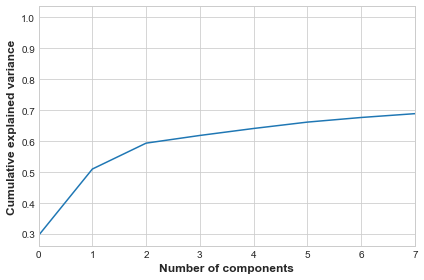

In [29]:
from sklearn.decomposition import PCA
pca = PCA().fit(data_scaled)
pca_transformed = pca.transform(data_scaled)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlim(0,7,1)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')

In [19]:
np.set_printoptions(suppress=True, precision=4)
print(pca.explained_variance_ratio_)
np.set_printoptions()  # reset print options

[0.2963 0.214  0.0835 0.0248 0.0225 0.0206 0.0149 0.0124 0.0103 0.0092
 0.0077 0.0072 0.0071 0.0068 0.0065 0.0062 0.0059 0.0059 0.0055 0.0055
 0.0053 0.0052 0.0052 0.0051 0.005  0.0049 0.0048 0.0047 0.0046 0.0044
 0.0044 0.0044 0.0043 0.0042 0.0042 0.0042 0.0041 0.0041 0.0041 0.004
 0.004  0.004  0.0039 0.0039 0.0039 0.0039 0.0038 0.0038 0.0037 0.0036
 0.0036 0.0035 0.0035 0.0033 0.0033 0.0033 0.0032 0.0031 0.0031 0.003
 0.003  0.0029 0.0029 0.0028 0.0027 0.0026 0.0025 0.0025 0.0023 0.0022
 0.0022 0.0022 0.0021 0.002  0.0018 0.0018 0.0016 0.0015 0.0014 0.0013
 0.0012 0.0011 0.0011 0.001  0.0009 0.0009 0.0008 0.0007 0.0007 0.0007
 0.0006 0.0006 0.0006 0.0006 0.0006 0.0005 0.0005 0.0005 0.0005 0.0004
 0.0004 0.0004 0.0004 0.0004 0.0003 0.0003 0.0003 0.0003 0.0003 0.0002
 0.0002 0.0002 0.0002 0.0002 0.0002 0.0002 0.0001 0.0001 0.0001 0.0001
 0.0001 0.0001 0.0001 0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0

array([<AxesSubplot:title={'center':'% Explained Variance'}, xlabel='Component'>,
       <AxesSubplot:title={'center':'% Cumulative Variance'}, xlabel='Component'>],
      dtype=object)

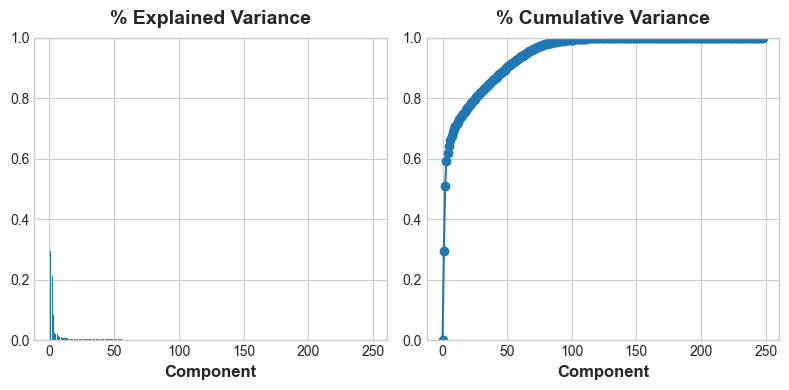

In [20]:
plot_variance(pca)

In [53]:
# pd_pca = pd.DataFrame(pca_transformed, columns=x_cols_numeric)
pd_pca 

,0,1,2,3,4,5,6,7,8,9,...,238,239,240,241,242,243,244,245,246,247
0,4.208044,14.726512,0.060213,-3.164430,0.596137,3.023349,7.049440,-1.581417,2.686048,0.789278,...,-3.342118e-16,-2.017112e-17,4.687505e-16,-9.776395e-16,-7.525948e-17,-6.689556e-16,5.524928e-17,5.156061e-16,-4.024485e-16,-5.118758e-16
1,4.392286,14.740376,0.321541,-2.263908,-0.328315,2.723107,7.365109,-2.658902,2.502993,0.963465,...,-2.946493e-17,-1.664417e-16,2.584387e-16,-5.227007e-16,7.897340e-17,1.125945e-15,-8.725239e-16,-6.396272e-16,8.208633e-16,-7.065507e-16
2,5.117881,13.981816,-0.000215,-5.162492,4.366786,5.316368,6.925720,1.009602,2.163778,1.282340,...,-2.236684e-16,-1.211231e-17,7.943794e-17,-6.167036e-16,-4.150991e-16,-1.717121e-15,1.292455e-15,1.193273e-15,1.074581e-16,-3.126314e-16
3,4.590149,14.143718,-0.451937,-4.810436,2.518985,4.059900,6.534694,-0.708827,1.581965,-0.553913,...,-3.788305e-16,1.645480e-16,4.137400e-16,-4.957849e-16,-1.307750e-15,-1.834002e-15,1.868013e-15,1.442294e-15,6.355117e-16,-7.716555e-16
4,4.601825,14.249843,-0.298673,-4.143062,1.667112,3.659839,6.030498,-0.915850,1.968025,0.626050,...,-4.692314e-16,7.961840e-17,3.168438e-16,-4.336648e-16,1.499473e-16,-8.663419e-16,-8.779847e-17,3.003704e-16,-1.121601e-15,-1.238028e-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46784,-15.918490,3.974844,-8.156107,13.524302,7.986195,9.407715,2.621837,-2.235241,-2.516976,4.541797,...,-4.651212e-16,5.119837e-16,2.032837e-15,1.956279e-16,-6.340688e-15,6.474480e-17,2.969413e-15,-5.161962e-15,-1.545464e-15,-1.162476e-15
46785,-16.080836,4.486999,-7.412357,14.293253,8.036619,9.204197,1.921847,-2.569737,-1.551694,3.544221,...,-4.460771e-16,4.203852e-16,2.197027e-15,1.513270e-16,-6.008276e-15,-4.754572e-16,3.560167e-15,-5.319457e-15,-1.205767e-15,-1.451843e-15
46786,-16.051238,3.149889,-9.261552,12.477297,8.334115,8.845336,3.658672,-0.971300,-2.318278,2.856930,...,-7.185330e-16,3.610195e-16,1.054333e-15,2.028795e-16,-5.487994e-15,-1.444282e-15,3.940504e-15,-3.747761e-15,-1.111799e-15,-1.662883e-15
46787,-15.795380,0.632974,-10.808581,11.134851,9.387622,9.988235,9.869700,1.120044,-5.378580,5.830270,...,-4.459292e-17,1.389749e-16,9.988214e-16,2.881085e-17,-7.677215e-15,-3.331661e-15,-2.783436e-16,-3.608984e-15,-1.999977e-15,-1.718394e-15


In [47]:
pca_transformed

array([[  4.208 ,  14.7265,   0.0602, ...,   0.    ,  -0.    ,  -0.    ],
       [  4.3923,  14.7404,   0.3215, ...,  -0.    ,   0.    ,  -0.    ],
       [  5.1179,  13.9818,  -0.0002, ...,   0.    ,   0.    ,  -0.    ],
       ...,
       [-16.0512,   3.1499,  -9.2616, ...,  -0.    ,  -0.    ,  -0.    ],
       [-15.7954,   0.633 , -10.8086, ...,  -0.    ,  -0.    ,  -0.    ],
       [-15.8303,  -0.0985, -11.7717, ...,  -0.    ,  -0.    ,  -0.    ]])

In [36]:
pca.explained_variance_ratio_

array([0.2963, 0.214 , 0.0835, 0.0248, 0.0225, 0.0206, 0.0149, 0.0124,
       0.0103, 0.0092, 0.0077, 0.0072, 0.0071, 0.0068, 0.0065, 0.0062,
       0.0059, 0.0059, 0.0055, 0.0055, 0.0053, 0.0052, 0.0052, 0.0051,
       0.005 , 0.0049, 0.0048, 0.0047, 0.0046, 0.0044, 0.0044, 0.0044,
       0.0043, 0.0042, 0.0042, 0.0042, 0.0041, 0.0041, 0.0041, 0.004 ,
       0.004 , 0.004 , 0.0039, 0.0039, 0.0039, 0.0039, 0.0038, 0.0038,
       0.0037, 0.0036, 0.0036, 0.0035, 0.0035, 0.0033, 0.0033, 0.0033,
       0.0032, 0.0031, 0.0031, 0.003 , 0.003 , 0.0029, 0.0029, 0.0028,
       0.0027, 0.0026, 0.0025, 0.0025, 0.0023, 0.0022, 0.0022, 0.0022,
       0.0021, 0.002 , 0.0018, 0.0018, 0.0016, 0.0015, 0.0014, 0.0013,
       0.0012, 0.0011, 0.0011, 0.001 , 0.0009, 0.0009, 0.0008, 0.0007,
       0.0007, 0.0007, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0005,
       0.0005, 0.0005, 0.0005, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004,
       0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0002, 0.0002, 0.0002,
      

In [64]:
print(pd.DataFrame(pca_transformed,columns=x_cols_numeric))

          con_id       time        bid   bid_size        ask   ask_size  \
0       4.208044  14.726512   0.060213  -3.164430   0.596137   3.023349   
1       4.392286  14.740376   0.321541  -2.263908  -0.328315   2.723107   
2       5.117881  13.981816  -0.000215  -5.162492   4.366786   5.316368   
3       4.590149  14.143718  -0.451937  -4.810436   2.518985   4.059900   
4       4.601825  14.249843  -0.298673  -4.143062   1.667112   3.659839   
...          ...        ...        ...        ...        ...        ...   
46784 -15.918490   3.974844  -8.156107  13.524302   7.986195   9.407715   
46785 -16.080836   4.486999  -7.412357  14.293253   8.036619   9.204197   
46786 -16.051238   3.149889  -9.261552  12.477297   8.334115   8.845336   
46787 -15.795380   0.632974 -10.808581  11.134851   9.387622   9.988235   
46788 -15.830288  -0.098533 -11.771683  11.177843  10.066062  10.318996   

            last  last_size    volume  hist_volatility  ...   p30s_bucket  \
0       7.049440  -1.5

In [62]:
x_cols_numeric.shape

(267,)

In [73]:
p_pd = pd.DataFrame([ x_cols_numeric, pca.explained_variance_ratio_], index=["col_name","priority"])

In [77]:
 x_cols_numeric

Index(['con_id', 'time', 'bid', 'bid_size', 'ask', 'ask_size', 'last',
       'last_size', 'volume', 'hist_volatility',
       ...
       'p30s_bucket', 'p60s_bucket', 'p300s_bucket', 'p600s_bucket',
       'n5s_bucket', 'n15s_bucket', 'n30s_bucket', 'n60s_bucket',
       'n300s_bucket', 'n600s_bucket'],
      dtype='object', length=248)